# Eigenportfolios from US Equities

**Docker image**: `ml4t`

**Chapter 14: Latent Factors**
**Section Reference**: Section 14.3 (Eigenportfolios for Equity Strategies)

## Purpose
This notebook applies PCA to a liquid subset of the US Equities dataset to extract latent
risk factors and construct gross-normalized eigenportfolios. It demonstrates standard PCA,
sector loading analysis, hierarchical PCA (HPCA), residual diagnostics, risk decomposition,
loading stability, and an as-of-end-date two-speed covariance estimate.

## Where this fits in the framework

This notebook stays within **Stage 1** of the two-step latent-factor
framework (Figure 14.9). The PCA decomposition produces factors $F$
(eigenportfolios) and loadings $B$ (factor exposures); these are the
Stage 1 outputs that downstream notebooks combine with Stage 2 forecasters
to produce return forecasts. Eigenportfolios are also natural risk-model
inputs in their own right; see the statistical arbitrage and risk
decomposition sections.

## Learning Objectives
- LO1: Apply PCA to large cross-sectional equity data and interpret variance decomposition
- LO2: Interpret eigenportfolios economically via sector loading analysis
- LO3: Implement Hierarchical PCA (HPCA) for improved factor interpretability
- LO4: Diagnose residual persistence and decompose portfolio risk without making a trading claim
- LO5: Separate sign ambiguity from subspace drift in rolling PCA

**Prerequisites**: Complete [`01_pca_equity_sectors`](01_pca_equity_sectors.ipynb); requires US equities data.

## Cross-References
- **Upstream**: [`01_pca_equity_sectors`](01_pca_equity_sectors.ipynb) (sector ETF PCA, bootstrap stability)
- **Downstream**: Chapter 18 (factor-based portfolio construction)
- **Related**: Section 9.4 (HMM regimes for factor timing)

## Data Source
US Equities (NASDAQ Data Link), with sector ETF returns used only for descriptive labels

## 1. Setup and Imports

In [1]:
"""Eigenportfolios: large-scale PCA factor extraction from US equities."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

from data import load_etfs, load_us_equities
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, add_message_title, zero_line

In [2]:
# Production defaults (Papermill overrides for CI testing)
N_COMPONENTS = 10
MIN_OBSERVATIONS = 252
TOP_N_STOCKS = 500
START_DATE = "2006-01-01"
END_DATE = "2018-03-27"
ROLL_WINDOW = 252
ROLL_STEP = 21
N_ROLL_PCS = 5
FAST_HALFLIFE = 20
SLOW_HALFLIFE = 120
N_PROD_FACTORS = 5
DIAGONAL_SHRINKAGE = 0.10
SEED = 42

In [3]:
set_global_seeds(SEED)
rng = np.random.default_rng(SEED)

print(f"Eigenportfolios: top {TOP_N_STOCKS} stocks, {START_DATE} to {END_DATE}, {N_COMPONENTS} PCs")

Eigenportfolios: top 500 stocks, 2006-01-01 to 2018-03-27, 10 PCs


## 2. Load US Equities Data

US Equities contains adjusted OHLCV for 3,199 stocks from 1962–2018.

In [4]:
equities = load_us_equities(start_date=START_DATE, end_date=END_DATE)

print(f"Raw data: {len(equities):,} rows, {equities['symbol'].n_unique():,} assets")
print(f"Date range: {equities['timestamp'].min()} to {equities['timestamp'].max()}")

Raw data: 8,314,914 rows, 3,199 assets
Date range: 2006-01-02 to 2018-03-27


## 3. Universe Selection: Top N by Dollar Volume

We select the most liquid stocks by average dollar volume over the declared sample. This is a
descriptive, full-sample universe definition. It must not be reused as a point-in-time trading
universe because later observations affect which stocks qualify.

In [5]:
dollar_volume = (
    equities.group_by("symbol")
    .agg(
        pl.col("adj_close").mean().alias("avg_price"),
        pl.col("volume").mean().alias("avg_volume"),
        pl.col("timestamp").count().alias("n_days"),
    )
    .with_columns((pl.col("avg_price") * pl.col("avg_volume")).alias("dollar_volume"))
    .filter(pl.col("n_days") >= MIN_OBSERVATIONS)
    .sort("dollar_volume", descending=True)
)

selected_assets = dollar_volume.head(TOP_N_STOCKS)["symbol"].to_list()
equities_universe = equities.filter(pl.col("symbol").is_in(selected_assets))
print(
    f"Selected {len(selected_assets)} assets (min {MIN_OBSERVATIONS} days), {len(equities_universe):,} rows"
)

Selected 500 assets (min 252 days), 1,411,307 rows


## 4. Compute Returns and Create Return Matrix

In [6]:
returns_long = (
    equities_universe.sort(["symbol", "timestamp"])
    .with_columns(pl.col("adj_close").pct_change().over("symbol").alias("return"))
    .drop_nulls(subset=["return"])
    .select(["timestamp", "symbol", "return"])
)

all_dates = returns_long.select("timestamp").unique().sort("timestamp")
n_total_days = len(all_dates)

# Require at least 90% coverage
min_coverage = int(n_total_days * 0.9)
stock_coverage = (
    returns_long.group_by("symbol")
    .agg(pl.len().alias("n_days"))
    .filter(pl.col("n_days") >= min_coverage)
)
well_covered = stock_coverage["symbol"].to_list()

returns_filtered = returns_long.filter(pl.col("symbol").is_in(well_covered))
returns_wide = returns_filtered.pivot(on="symbol", index="timestamp", values="return").sort(
    "timestamp"
)

dates = returns_wide["timestamp"].to_pandas()
symbol_cols = [c for c in returns_wide.columns if c != "timestamp"]
returns_matrix = returns_wide.select(symbol_cols).to_pandas()

# Record the remaining missingness, then use zero as an explicit covariance-estimation convention.
# Zero filling can attenuate covariance for stocks with gaps; the effect is not assumed negligible.
missing_share = returns_matrix.isna().to_numpy().mean()
returns_matrix = returns_matrix.fillna(0)
final_symbols = returns_matrix.columns.tolist()

print(
    f"Return matrix: {returns_matrix.shape[0]:,} days x {returns_matrix.shape[1]} stocks; "
    f"zero-filled cells: {missing_share:.2%}"
)

Return matrix: 3,078 days x 401 stocks; zero-filled cells: 0.62%


**NaN handling**: Missing returns are filled with zero after a 90% coverage filter. This
attenuates covariance for stocks with gaps, so the printed missing-cell share is part of the
result. A production estimate should compare this convention with a complete-case or
missing-data covariance estimator.

## 5. PCA: Extract Eigenportfolios

In [7]:
scaler = StandardScaler()
returns_scaled = scaler.fit_transform(returns_matrix)

pca = PCA(n_components=N_COMPONENTS, random_state=SEED)
pca.fit(returns_scaled)
factor_scores = pca.transform(returns_scaled)

# A standardized-space eigenvector v maps to raw-return weights v / sigma. Normalize by gross
# exposure, not by the signed sum, and orient PC1 toward the equal-weight market.
raw_weights = pca.components_ / scaler.scale_[None, :]
if raw_weights[0].sum() < 0:
    pca.components_[0] *= -1
    factor_scores[:, 0] *= -1
    raw_weights[0] *= -1
eigenweights = raw_weights / np.abs(raw_weights).sum(axis=1, keepdims=True)
factor_returns = returns_matrix.to_numpy() @ eigenweights.T

### Variance Decomposition

In [8]:
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print(
    f"Variance explained: PC1={explained_var[0]:.2%}; "
    f"first 5={cumulative_var[4]:.2%}; first 10={cumulative_var[-1]:.2%}"
)

Variance explained: PC1=38.29%; first 5=48.14%; first 10=52.22%


**Finding**: PC1 alone captures a substantial share of total variance as the dominant market
factor. The first 5 components together explain roughly half the cross-sectional variation,
with diminishing returns beyond PC5.

## 6. Scree Plot

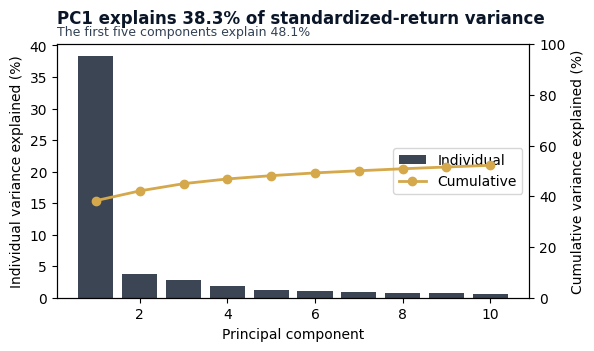

In [9]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"], constrained_layout=True)
bars = ax.bar(range(1, N_COMPONENTS + 1), explained_var * 100, color=COLORS["blue"], alpha=0.8)
ax_cumulative = ax.twinx()
(cumulative_line,) = ax_cumulative.plot(
    range(1, N_COMPONENTS + 1),
    cumulative_var * 100,
    "o-",
    color=COLORS["amber"],
    linewidth=2,
)
ax.set_xlabel("Principal component")
ax.set_ylabel("Individual variance explained (%)")
ax_cumulative.set_ylabel("Cumulative variance explained (%)")
ax_cumulative.set_ylim(0, 100)
ax.legend([bars, cumulative_line], ["Individual", "Cumulative"], loc="center right")
add_message_title(
    ax,
    f"PC1 explains {explained_var[0]:.1%} of standardized-return variance",
    subtitle=f"The first five components explain {cumulative_var[4]:.1%}",
)

fig.show()

## 7. Eigenportfolio Loadings

The PCA eigenvectors define portfolio weights. Positive and negative loadings create
long-short factor portfolios.

In [10]:
loadings = pca.components_  # standardized-space eigenvectors, (components, stocks)
loadings_df = pd.DataFrame(
    loadings[:5].T, index=final_symbols, columns=[f"PC{i + 1}" for i in range(5)]
)

Each eigenvector defines portfolio weights. The $k$-th eigenportfolio weight vector is:

$$w_k = \frac{v_k}{\|v_k\|_1}$$

where $v_k$ is converted from standardized to raw-return space and $\|w_k\|_1=1$ fixes
gross exposure. L1 normalization does not make signed weights sum to one.

### PC1 (Market Factor): Top and Bottom Weights

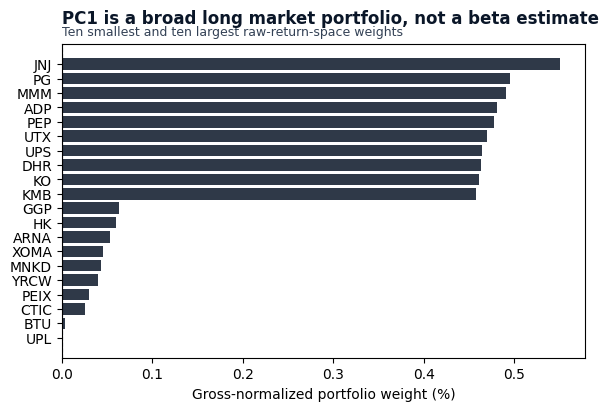

In [11]:
pc1_weights = pd.Series(eigenweights[0], index=final_symbols).sort_values()
weight_extremes = pd.concat([pc1_weights.head(10), pc1_weights.tail(10)]) * 100
fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"], constrained_layout=True)
bar_colors = [COLORS["negative"] if value < 0 else COLORS["blue"] for value in weight_extremes]
ax.barh(weight_extremes.index, weight_extremes.values, color=bar_colors, alpha=0.85)
zero_line(ax, axis="x")
ax.set_xlabel("Gross-normalized portfolio weight (%)")
add_message_title(
    ax,
    "PC1 is a broad long market portfolio, not a beta estimate",
    subtitle="Ten smallest and ten largest raw-return-space weights",
)
fig.show()

**Interpretation**: PC1 weights are predominantly positive, confirming its role as a broad
market mode. Their magnitude is a PCA portfolio weight, not CAPM beta; economic labels require
separate characteristics or a prespecified market regression.

## 8. Sector Loading Heatmap (Figure 14.3)

To interpret eigenportfolios economically, we map stocks to approximate GICS sectors
using their correlations with sector ETFs. This data-driven approach avoids requiring
an external sector lookup table.

In [12]:
# Load sector ETF returns for the same period
sector_etfs = {
    "XLB": "Materials",
    "XLE": "Energy",
    "XLF": "Financials",
    "XLI": "Industrials",
    "XLK": "Technology",
    "XLP": "Staples",
    "XLU": "Utilities",
    "XLV": "Healthcare",
    "XLY": "Discretionary",
}

etf_data = load_etfs(
    symbols=list(sector_etfs.keys()), start_date=START_DATE, end_date=END_DATE
).select(["timestamp", "symbol", "close"])

etf_prices = (
    etf_data.pivot(on="symbol", index="timestamp", values="close")
    .sort("timestamp")
    .to_pandas()
    .set_index("timestamp")
)
etf_returns = etf_prices.pct_change().dropna()

### Map Stocks to Sectors via Correlation

We assign each stock to its highest-correlation sector ETF using overlapping
return dates, providing a data-driven sector classification.

In [13]:
# Align dates between equities and ETF returns
equities_returns_pd = returns_matrix.copy()
equities_returns_pd.index = dates.values[: len(equities_returns_pd)]

overlap_dates = sorted(set(equities_returns_pd.index) & set(etf_returns.index))
equities_aligned = equities_returns_pd.loc[overlap_dates]
etf_aligned = etf_returns.loc[overlap_dates]

# Vectorized correlation: corrwith computes column-wise correlation in one pass
sector_corr = pd.DataFrame(
    {
        etf: equities_aligned.corrwith(etf_aligned[etf])
        for etf in sector_etfs
        if etf in etf_aligned.columns
    }
)

sector_assignment = sector_corr.idxmax(axis=1).map(sector_etfs)
sector_assignment.name = "Sector"

print(
    f"Sector proxy labels: {sector_assignment.notna().sum()} stocks across "
    f"{sector_assignment.nunique()} sectors and {len(overlap_dates)} overlapping dates"
)

Sector proxy labels: 401 stocks across 9 sectors and 3077 overlapping dates


### Compute Mean Loadings by Sector

In [14]:
# Add sector to loadings and compute mean per sector
loadings_with_sector = loadings_df.copy()
loadings_with_sector["Sector"] = sector_assignment.reindex(loadings_with_sector.index)

sector_loadings = loadings_with_sector.groupby("Sector")[["PC1", "PC2", "PC3", "PC4", "PC5"]].mean()

# Sort sectors by PC1 loading for visual clarity
sector_loadings = sector_loadings.sort_values("PC1", ascending=False)

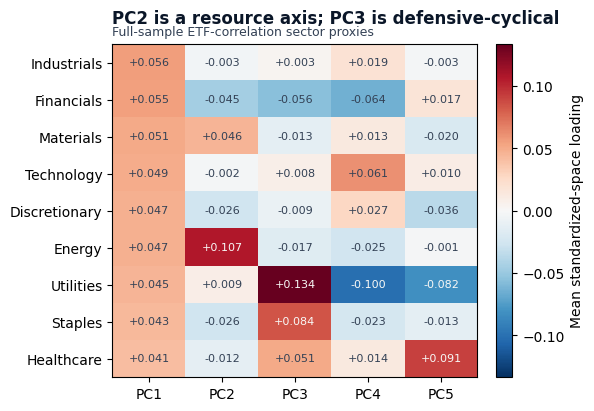

In [15]:
# Figure 14.3: Sector loading heatmap
fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"], constrained_layout=True)
limit = float(np.abs(sector_loadings.to_numpy()).max())
image = ax.imshow(sector_loadings.to_numpy(), cmap="RdBu_r", vmin=-limit, vmax=limit, aspect="auto")
ax.set_xticks(range(sector_loadings.shape[1]), sector_loadings.columns)
ax.set_yticks(range(sector_loadings.shape[0]), sector_loadings.index)
for row in range(sector_loadings.shape[0]):
    for col in range(sector_loadings.shape[1]):
        value = sector_loadings.iloc[row, col]
        text_color = COLORS["silver"] if abs(value) > 0.55 * limit else COLORS["neutral"]
        ax.text(
            col,
            row,
            f"{value:+.3f}",
            ha="center",
            va="center",
            fontsize=8,
            color=text_color,
        )
fig.colorbar(image, ax=ax, label="Mean standardized-space loading")
add_message_title(
    ax,
    "PC2 is a resource axis; PC3 is defensive-cyclical",
    subtitle="Full-sample ETF-correlation sector proxies",
)
fig.show()

**Finding**: PC1 loads positively across all sectors with tightly clustered values
(0.041–0.056), reflecting the broad market factor. PC2 is dominated by Energy
(+0.107) and Materials (+0.046) versus Financials (-0.045), Discretionary (-0.026), and
Staples (-0.026), a commodity / cyclical-resource axis rather than the growth-vs-defensive
rotation that one might expect. The conventional defensive-vs-cyclical pattern instead
appears in PC3, with Utilities (+0.134), Staples (+0.084), and Healthcare (+0.051) on the
defensive side and Financials (-0.056), Energy (-0.017), and Materials (-0.013) on the
cyclical side. This ordering of factor interpretation is universe- and period-specific:
on a 2006–2018 top-500 US equity panel, commodity exposure dominates PC2 because
Energy and Materials returns share a strong common driver outside the broad market.
Higher-order components capture progressively more nuanced sector tilts.

## 9. Eigenportfolio Score Trajectories

Standardized PCA scores cannot be compounded as returns. Instead, we apply the
gross-normalized raw-return-space weights derived in Section 7 to each day's stock returns.
These are actual in-sample portfolio returns. Their signs remain conventional for PC2 onward,
and their paths are descriptive rather than out-of-sample performance estimates.

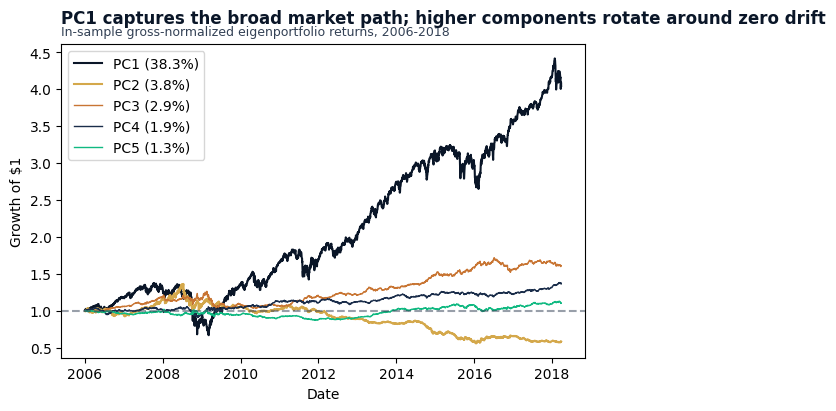

In [16]:
factor_returns_df = pd.DataFrame(
    {f"PC{i + 1}": factor_returns[:, i] for i in range(N_COMPONENTS)},
    index=dates.values[: len(factor_scores)],
)

cum_factors = (1 + factor_returns_df[["PC1", "PC2", "PC3", "PC4", "PC5"]]).cumprod()

fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"], constrained_layout=True)
for i, col in enumerate(cum_factors.columns):
    ax.plot(
        cum_factors.index,
        cum_factors[col],
        label=f"{col} ({explained_var[i]:.1%})",
        linewidth=1.5 if i < 2 else 1,
        color=[
            COLORS["blue"],
            COLORS["amber"],
            COLORS["copper"],
            COLORS["slate"],
            COLORS["positive"],
        ][i],
    )

ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
ax.legend(loc="upper left")
ax.axhline(y=1, color=COLORS["neutral"], linestyle="--", alpha=0.5)
add_message_title(
    ax,
    "PC1 captures the broad market path; higher components rotate around zero drift",
    subtitle="In-sample gross-normalized eigenportfolio returns, 2006-2018",
)
fig.show()

**Finding**: PC1 tracks the broad equity market because its raw-return-space weights are
predominantly positive. PC2 through PC5 are long-short portfolios whose paths depend on the
arbitrary component sign, so direction is not an economic forecast. For regime-switching models
applied to factor histories, see Section 9.4 (HMM).

## 10. Factor Characteristics

In [17]:
factor_stats = pd.DataFrame(
    {
        "Annualized volatility": factor_returns_df.iloc[:, :5].std() * np.sqrt(252),
        "Skew": factor_returns_df.iloc[:, :5].skew(),
        "Excess kurtosis": factor_returns_df.iloc[:, :5].kurtosis(),
    }
)
print(
    "Eigenportfolio annualized volatility: "
    + ", ".join(f"{idx}={value:.1%}" for idx, value in factor_stats.iloc[:, 0].items())
)

Eigenportfolio annualized volatility: PC1=21.1%, PC2=10.5%, PC3=6.8%, PC4=5.8%, PC5=5.0%


**Interpretation**: The gross-normalized portfolios are valid return series, but their gross
normalization differs by component, so their volatility ranking need not equal the standardized
score eigenvalue ranking. In-sample mean return or Sharpe is not a forecast. Risk premia require a
separately specified Stage 2 factor-premium forecast and a point-in-time evaluation.

## 11. Market Factor Validation

In [18]:
market_return = returns_matrix.mean(axis=1).values
pc1_return = factor_returns[:, 0]
market_corr = np.corrcoef(pc1_return, market_return)[0, 1]

print(f"Correlation(PC1, Equal-Weight Market): {market_corr:.4f}")
print(f"PC1 variance explained: {explained_var[0]:.1%}")

Correlation(PC1, Equal-Weight Market): 0.9886
PC1 variance explained: 38.3%


A correlation above 0.90 confirms that PC1 captures the dominant broad-market mode in this
sample. Its PCA loading resembles a common-factor exposure but is not a CAPM beta or a pricing
statement.

## 12. Hierarchical PCA (HPCA)

Standard PCA produces factors that maximize variance globally, but higher-order components
can be difficult to interpret economically. Avellaneda's (2019) Hierarchical PCA addresses
this by injecting known economic structure.

**Step 1**: PCA within each sector to identify the dominant factor for Technology stocks,
another for Financials, etc.

**Step 2**: PCA across sector-level factors to capture cross-sector dynamics.

> **HPCA ≠ HRP.** Hierarchical PCA (factor discovery) and Hierarchical Risk Parity
> (portfolio construction, Chapter 19) share a name but not a purpose.

In [19]:
# Step 1: Intra-sector PCA
sector_factors = {}
sectors_with_data = sector_assignment.dropna().unique()
# Require at least 10 stocks per sector for meaningful PCA
valid_sectors = [s for s in sectors_with_data if (sector_assignment == s).sum() >= 10]

for sector in sorted(valid_sectors):
    sector_stocks = sector_assignment[sector_assignment == sector].index.tolist()
    sector_stocks = [s for s in sector_stocks if s in returns_matrix.columns]
    if len(sector_stocks) < 10:
        continue

    sector_returns = returns_matrix[sector_stocks]
    sector_scaled = StandardScaler().fit_transform(sector_returns)

    # Extract first factor within each sector
    sector_pca = PCA(n_components=1, random_state=SEED)
    sector_factor = sector_pca.fit_transform(sector_scaled)
    sector_factors[sector] = sector_factor.flatten()

print(f"HPCA Step 1: Extracted intra-sector factors for {len(sector_factors)} sectors")
print(
    "Sector counts: "
    + ", ".join(
        f"{sector}={(sector_assignment == sector).sum()}" for sector in sorted(valid_sectors)
    )
)

HPCA Step 1: Extracted intra-sector factors for 9 sectors
Sector counts: Discretionary=86, Energy=50, Financials=62, Healthcare=43, Industrials=43, Materials=25, Staples=19, Technology=59, Utilities=14


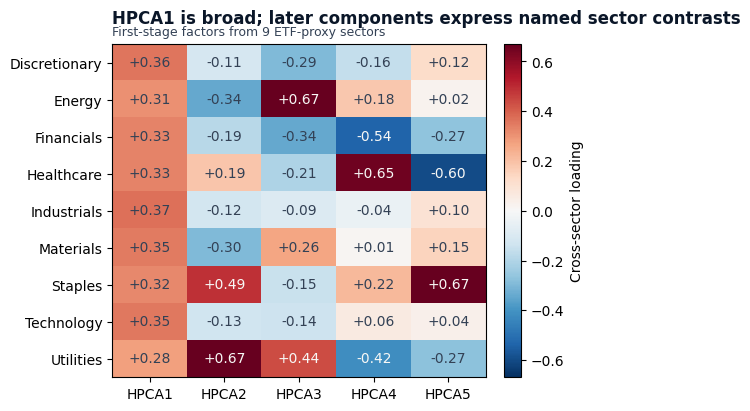

In [20]:
# Step 2: Cross-sector PCA
sector_factor_matrix = pd.DataFrame(sector_factors)

# Standardize sector factors
sector_scaler = StandardScaler()
sector_scaled = sector_scaler.fit_transform(sector_factor_matrix)

# PCA on sector-level factors
n_cross = min(5, len(sector_factors))
hpca = PCA(n_components=n_cross, random_state=SEED)
hpca.fit(sector_scaled)

# Display cross-sector loadings
hpca_loadings = pd.DataFrame(
    hpca.components_.T,
    index=sector_factor_matrix.columns,
    columns=[f"HPCA{i + 1}" for i in range(n_cross)],
)

fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"], constrained_layout=True)
hpca_limit = float(np.abs(hpca_loadings.to_numpy()).max())
image = ax.imshow(
    hpca_loadings.to_numpy(), cmap="RdBu_r", vmin=-hpca_limit, vmax=hpca_limit, aspect="auto"
)
ax.set_xticks(range(n_cross), hpca_loadings.columns)
ax.set_yticks(range(len(hpca_loadings)), hpca_loadings.index)
for row in range(hpca_loadings.shape[0]):
    for col in range(hpca_loadings.shape[1]):
        value = hpca_loadings.iloc[row, col]
        text_color = COLORS["silver"] if abs(value) > 0.55 * hpca_limit else COLORS["neutral"]
        ax.text(col, row, f"{value:+.2f}", ha="center", va="center", color=text_color)
fig.colorbar(image, ax=ax, label="Cross-sector loading")
add_message_title(
    ax,
    "HPCA1 is broad; later components express named sector contrasts",
    subtitle=f"First-stage factors from {len(valid_sectors)} ETF-proxy sectors",
)
fig.show()

**Finding**: HPCA produces cross-sector factors with clear economic interpretation.
HPCA1 typically captures the broad market (positive loadings across all sectors, mirroring
standard PC1). HPCA2 and beyond reveal sector-vs-sector dynamics that are easier to
label than standard PCA higher-order components, because each row corresponds to a named
sector rather than an anonymous stock.

## 13. Statistical Arbitrage: Residual Analysis

Regressing individual stock returns on the top-K eigenportfolios isolates residuals
hypothesized to mean-revert. We estimate the Ornstein-Uhlenbeck half-life:

$$t_{1/2} = -\frac{\ln 2}{\ln |\phi|}$$

where $\phi$ is the AR(1) slope. A positive $0 < \phi < 1$ maps to an OU-style half-life;
negative slopes imply alternating signs and are reported without an OU half-life.

**Caveat**: mean-reversion parameters are unstable
out-of-sample and transaction costs typically dominate any theoretical edge.

In [21]:
# Select a handful of stocks for demonstration
sample_stocks = rng.choice(final_symbols, size=min(5, len(final_symbols)), replace=False).tolist()
n_factors_regress = 5

# Regress each stock on top-K eigenportfolios
residuals_dict = {}
for stock in sample_stocks:
    y = returns_matrix[stock].values
    X = factor_scores[:, :n_factors_regress]
    reg = LinearRegression().fit(X, y)
    residuals_dict[stock] = y - reg.predict(X)

residuals_df = pd.DataFrame(residuals_dict, index=dates.values[: len(factor_scores)])

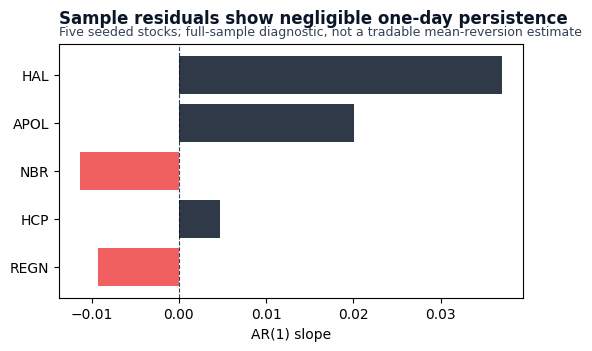

In [22]:
# Estimate OU half-life from residual autocorrelation
halflife_results = []
for stock in sample_stocks:
    resid = residuals_df[stock].values
    # AR(1) slope via OLS with an intercept
    resid_lag = resid[:-1]
    resid_cur = resid[1:]
    phi = float(LinearRegression().fit(resid_lag[:, None], resid_cur).coef_[0])
    halflife = -np.log(2) / np.log(phi) if 0 < phi < 1 else np.nan
    halflife_results.append({"Stock": stock, "AR(1) Coeff": phi, "Half-Life (days)": halflife})

halflife_df = pd.DataFrame(halflife_results).set_index("Stock")
fig, ax = plt.subplots(figsize=FIGSIZE["single"], constrained_layout=True)
colors = [
    COLORS["blue"] if value > 0 else COLORS["negative"] for value in halflife_df["AR(1) Coeff"]
]
ax.barh(halflife_df.index, halflife_df["AR(1) Coeff"], color=colors, alpha=0.85)
zero_line(ax, axis="x")
ax.set_xlabel("AR(1) slope")
add_message_title(
    ax,
    "Sample residuals show negligible one-day persistence",
    subtitle="Five seeded stocks; full-sample diagnostic, not a tradable mean-reversion estimate",
)
fig.show()

**Interpretation**: Slopes near zero indicate little one-day residual persistence in this
seeded sample. Negative slopes do not admit the positive-$\phi$ OU half-life formula. The
full-sample fit, random stock choice, and absence of cost-aware out-of-sample evaluation rule
out a trading conclusion.

## 14. Risk Decomposition

Any portfolio's total risk can be decomposed into exposures (betas) to the orthogonal
eigenportfolios. This provides a data-driven view of underlying risk drivers.

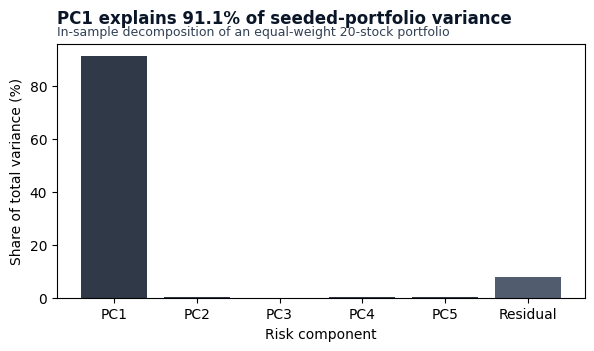

In [23]:
# Example: equal-weight portfolio of 20 random stocks
portfolio_stocks = rng.choice(
    final_symbols, size=min(20, len(final_symbols)), replace=False
).tolist()
portfolio_returns = returns_matrix[portfolio_stocks].mean(axis=1).values

# Regress on the five actual gross-normalized eigenportfolio return series.
X_factors = factor_returns[:, :5]
reg_portfolio = LinearRegression().fit(X_factors, portfolio_returns)

factor_var = np.var(X_factors * reg_portfolio.coef_[None, :], axis=0)
residual_var = np.var(portfolio_returns - reg_portfolio.predict(X_factors))
total_var = np.var(portfolio_returns)

decomp = pd.DataFrame(
    {
        "Beta": reg_portfolio.coef_,
        "Factor Variance Contrib (1e-5)": factor_var * 1e5,
        "% of Total Var": factor_var / total_var * 100,
    },
    index=[f"PC{i + 1}" for i in range(5)],
)
decomp.loc["Residual"] = [np.nan, residual_var * 1e5, residual_var / total_var * 100]

fig, ax = plt.subplots(figsize=FIGSIZE["single"], constrained_layout=True)
ax.bar(
    decomp.index,
    decomp["% of Total Var"],
    color=[COLORS["blue"]] * 5 + [COLORS["neutral"]],
    alpha=0.85,
)
ax.set_ylabel("Share of total variance (%)")
ax.set_xlabel("Risk component")
add_message_title(
    ax,
    f"PC1 explains {decomp.loc['PC1', '% of Total Var']:.1f}% of seeded-portfolio variance",
    subtitle="In-sample decomposition of an equal-weight 20-stock portfolio",
)
fig.show()

**Finding**: The market factor (PC1) dominates portfolio risk, explaining
the largest share of total variance for this seeded portfolio. This is an in-sample
attribution, not a universal 80-90% range or a hedge recommendation. The residual is variation
not spanned by the first five fitted components.

## 15. Eigenvector Stability: Cosine Similarity and Procrustes Rotation

Rolling PCA loadings can "flip" between adjacent windows when eigenvalues are
close in magnitude, a mathematical pathology rather than a structural change. This
creates phantom turnover in downstream allocation. We diagnose this with cosine
similarity, then fix it with Procrustes rotation (Section 14.3).

In [24]:
# Rolling PCA with monthly re-estimation; each window ends before its displayed month.
loading_history = []
loading_dates = []
for end_idx in range(ROLL_WINDOW, len(returns_matrix), ROLL_STEP):
    window = returns_matrix.iloc[end_idx - ROLL_WINDOW : end_idx].values
    valid_cols = ~np.isnan(window).any(axis=0)
    if valid_cols.sum() < N_ROLL_PCS + 5:
        continue
    window_clean = window[:, valid_cols]
    roll_scaler = StandardScaler()
    window_scaled = roll_scaler.fit_transform(window_clean)
    roll_pca = PCA(n_components=N_ROLL_PCS, random_state=SEED)
    roll_pca.fit(window_scaled)
    loading_history.append(roll_pca.components_)
    loading_dates.append(dates.iloc[end_idx])

print(f"Rolling PCA: {len(loading_history)} windows, {N_ROLL_PCS} components each")

Rolling PCA: 135 windows, 5 components each


In [25]:
# Signed and absolute cosine similarity between like-numbered consecutive eigenvectors.
signed_cosine = np.zeros((len(loading_history) - 1, N_ROLL_PCS))
for t in range(len(loading_history) - 1):
    for k in range(N_ROLL_PCS):
        v1 = loading_history[t][k]
        v2 = loading_history[t + 1][k]
        signed_cosine[t, k] = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

absolute_cosine = np.abs(signed_cosine)
sign_flip_counts = (signed_cosine < 0).sum(axis=0)
low_stability_counts = (absolute_cosine < 0.8).sum(axis=0)
print(
    "Raw rolling diagnostics: "
    + ", ".join(
        f"PC{k + 1} flips={sign_flip_counts[k]}, |cos|<0.8={low_stability_counts[k]}"
        for k in range(N_ROLL_PCS)
    )
)

Raw rolling diagnostics: PC1 flips=0, |cos|<0.8=0, PC2 flips=13, |cos|<0.8=5, PC3 flips=13, |cos|<0.8=8, PC4 flips=29, |cos|<0.8=10, PC5 flips=24, |cos|<0.8=24


**Finding**: The signed diagnostic separates arbitrary sign reversals from genuine loading
instability. The absolute diagnostic treats $v$ and $-v$ as equivalent; values below 0.8 then
flag rotations or component swaps that a sign correction alone cannot repair.

In [26]:
# Procrustes rotation: align each window's factor basis to the preceding aligned basis.
#
# Each `loading_history[t]` has shape (K, N), components by assets. The factor basis
# is the transpose: B_t = loading_history[t].T with shape (N, K). Procrustes alignment
# in factor space solves
#     min_{R: R^T R = I_K}  || B_t R - B_{t-1} ||_F
# whose closed-form solution is R = U V^T from SVD of (B_t^T B_{t-1}). The resulting R
# is K by K: a rotation in the K-dimensional factor space, not N by N.
#
# The coordinate rotation must also be applied to factor scores and factor covariance before
# downstream use; here it is only a loading-stability diagnostic.

aligned_bases = [loading_history[0].T]
procrustes_sim = np.zeros((len(loading_history) - 1, N_ROLL_PCS))

for t in range(1, len(loading_history)):
    prev_basis = aligned_bases[-1]
    curr_basis = loading_history[t].T  # (N, K)
    # K x K rotation that maps the current factor basis into the prior aligned frame
    U, _, Vt = np.linalg.svd(curr_basis.T @ prev_basis)
    rotation = U @ Vt  # (K, K), orthogonal
    aligned_basis = curr_basis @ rotation  # (N, K)
    aligned_bases.append(aligned_basis)
    for k in range(N_ROLL_PCS):
        v1 = prev_basis[:, k]
        v2 = aligned_basis[:, k]
        procrustes_sim[t - 1, k] = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

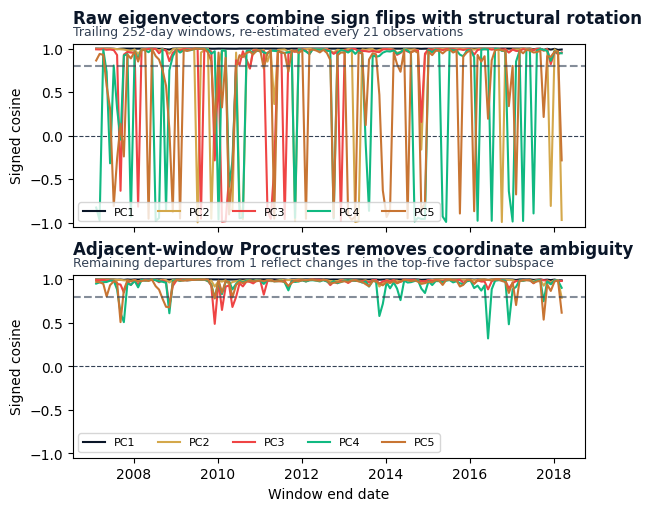

In [27]:
# Compare before/after
fig, axes = plt.subplots(
    2, 1, figsize=FIGSIZE["dual_v"], sharex=True, sharey=True, constrained_layout=True
)
palette = [
    COLORS["blue"],
    COLORS["amber"],
    COLORS["negative"],
    COLORS["positive"],
    COLORS["copper"],
]
for k in range(N_ROLL_PCS):
    axes[0].plot(loading_dates[1:], signed_cosine[:, k], label=f"PC{k + 1}", color=palette[k])
    axes[1].plot(loading_dates[1:], procrustes_sim[:, k], label=f"PC{k + 1}", color=palette[k])
for ax in axes:
    ax.axhline(0.8, color=COLORS["neutral"], linestyle="--", alpha=0.6)
    zero_line(ax)
    ax.legend(fontsize=8, loc="lower left", ncol=5)
    ax.set_ylim(-1.05, 1.05)
    ax.set_ylabel("Signed cosine")
axes[1].set_xlabel("Window end date")
add_message_title(
    axes[0],
    "Raw eigenvectors combine sign flips with structural rotation",
    subtitle="Trailing 252-day windows, re-estimated every 21 observations",
)
add_message_title(
    axes[1],
    "Adjacent-window Procrustes removes coordinate ambiguity",
    subtitle="Remaining departures from 1 reflect changes in the top-five factor subspace",
)
fig.show()

**Reading the figure**: The Procrustes rotation is a $K \times K$ orthogonal transform in
factor space, not an $N \times N$ asset-space rotation. Adjacent alignment removes arbitrary
signs and rotations inside the retained subspace. It does not prove that named PCs are stable,
nor does it by itself define production portfolio weights. A downstream covariance model must
rotate scores and factor covariance consistently and still monitor subspace drift.

## 16. Two-Stage Production PCA

Production risk models separate two dynamics: volatility changes quickly (days),
while correlation structure changes slowly (months). The two-stage procedure from
Paleologo (2025, Ch. 7) handles this separation. Stage 1 captures short-term
volatility; Stage 2 estimates the stable correlation factor structure.

In [28]:
# This is an as-of-END_DATE estimator, not a historical backtest.
ret_np = returns_matrix.values
T_full, N_full = ret_np.shape


def exp_weights(length, half_life):
    ages = np.arange(length)[::-1]
    weights = np.exp(-np.log(2) * ages / half_life)
    return weights / weights.sum()


def weighted_covariance(values, weights):
    mean = np.average(values, axis=0, weights=weights)
    centered = values - mean
    covariance = (centered * np.sqrt(weights[:, None])).T @ (centered * np.sqrt(weights[:, None]))
    return covariance, mean


# Stage 1: fast covariance, then residual volatility after removing five common components.
fast_weights = exp_weights(T_full, FAST_HALFLIFE)
fast_cov, _ = weighted_covariance(ret_np, fast_weights)
fast_eigenvalues, fast_eigenvectors = np.linalg.eigh(fast_cov)
fast_order = np.argsort(fast_eigenvalues)[::-1]
fast_eigenvalues = fast_eigenvalues[fast_order]
fast_eigenvectors = fast_eigenvectors[:, fast_order]
fast_common = (
    fast_eigenvectors[:, :N_PROD_FACTORS]
    @ np.diag(fast_eigenvalues[:N_PROD_FACTORS])
    @ fast_eigenvectors[:, :N_PROD_FACTORS].T
)
fast_residual_raw = np.clip(np.diag(fast_cov - fast_common), 1e-10, None)
fast_residual_var = (1 - DIAGONAL_SHRINKAGE) * fast_residual_raw + DIAGONAL_SHRINKAGE * np.median(
    fast_residual_raw
)
idio_vol = np.sqrt(fast_residual_var)

print(
    f"Stage 1: {FAST_HALFLIFE}-day half-life; median residual volatility={np.median(idio_vol):.4%}"
)

Stage 1: 20-day half-life; median residual volatility=1.0873%


In [29]:
# Stage 2: slow covariance on returns normalized by fast residual volatility.
slow_weights = exp_weights(T_full, SLOW_HALFLIFE)
ret_normalized = ret_np / idio_vol[None, :]
slow_cov, _ = weighted_covariance(ret_normalized, slow_weights)
slow_eigenvalues, slow_eigenvectors = np.linalg.eigh(slow_cov)
slow_order = np.argsort(slow_eigenvalues)[::-1]
slow_eigenvalues = slow_eigenvalues[slow_order]
slow_eigenvectors = slow_eigenvectors[:, slow_order]

# An exponentially weighted sample has fewer effective observations. Use that effective size
# in a BBP-informed threshold, then retain only excess eigenvalue above the estimated noise scale.
effective_t = 1 / np.square(slow_weights).sum()
noise_scale = float(np.median(np.diag(slow_cov)))
mp_upper = noise_scale * (1 + np.sqrt(N_full / effective_t)) ** 2
n_above_edge = int((slow_eigenvalues > mp_upper).sum())
n_signal = max(1, min(N_PROD_FACTORS, n_above_edge))
signal_eigenvalues = np.clip(slow_eigenvalues[:n_signal] - noise_scale, 0, None)

print(
    f"Stage 2: {n_above_edge} components clear the edge; {n_signal} retained; "
    f"BBP-informed upper edge={mp_upper:.2f}, effective T={effective_t:.1f}, N={N_full}"
)

Stage 2: 19 components clear the edge; 5 retained; BBP-informed upper edge=7.95, effective T=346.2, N=401


In [30]:
# Reconstruct covariance: Ω = D_σ (B Ω_f B^T + Ω_ε) D_σ
B = slow_eigenvectors[:, :n_signal]
Omega_f = np.diag(signal_eigenvalues)
common_cov = B @ Omega_f @ B.T
omega_eps_raw = np.clip(np.diag(slow_cov - common_cov), 1e-10, None)
omega_eps = (1 - DIAGONAL_SHRINKAGE) * omega_eps_raw + DIAGONAL_SHRINKAGE * np.median(omega_eps_raw)

cov_prod = np.diag(idio_vol) @ (B @ Omega_f @ B.T + np.diag(omega_eps)) @ np.diag(idio_vol)
std_cov = np.cov(ret_np.T)
standard_condition = np.linalg.cond(std_cov)
two_stage_condition = np.linalg.cond(cov_prod)

print(
    f"Condition number: standard={standard_condition:.0f}, two-stage={two_stage_condition:.0f}; "
    f"ratio={standard_condition / two_stage_condition:.1f}x"
)

shown = min(20, len(slow_eigenvalues))
spectrum_colors = [
    COLORS["blue"]
    if i < n_signal
    else COLORS["amber"]
    if slow_eigenvalues[i] > mp_upper
    else COLORS["silver_muted"]
    for i in range(shown)
]

Condition number: standard=72181, two-stage=57063; ratio=1.3x


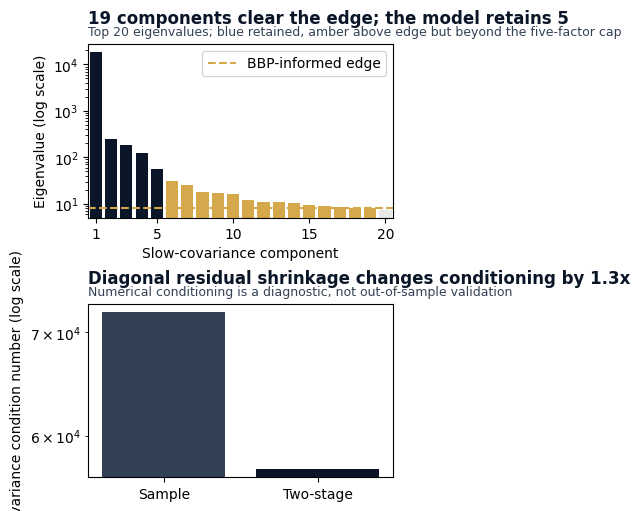

In [31]:
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE["dual_v"], constrained_layout=True)
axes[0].bar(
    np.arange(1, shown + 1),
    slow_eigenvalues[:shown],
    color=spectrum_colors,
)
axes[0].axhline(mp_upper, color=COLORS["amber"], linestyle="--", label="BBP-informed edge")
axes[0].set_xlabel("Slow-covariance component")
axes[0].set_xlim(0.5, shown + 0.5)
axes[0].set_xticks([1, 5, 10, 15, 20])
axes[0].set_yscale("log")
axes[0].set_ylabel("Eigenvalue (log scale)")
axes[0].legend()
add_message_title(
    axes[0],
    f"{n_above_edge} components clear the edge; the model retains {n_signal}",
    subtitle="Top 20 eigenvalues; blue retained, amber above edge but beyond the five-factor cap",
)
axes[1].bar(
    ["Sample", "Two-stage"],
    [standard_condition, two_stage_condition],
    color=[COLORS["neutral"], COLORS["blue"]],
)
axes[1].set_yscale("log")
axes[1].set_ylabel("Covariance condition number (log scale)")
add_message_title(
    axes[1],
    f"Diagonal residual shrinkage changes conditioning by {standard_condition / two_stage_condition:.1f}x",
    subtitle="Numerical conditioning is a diagnostic, not out-of-sample validation",
)
fig.show()

**Finding**: The as-of-end-date estimate separates fast residual volatility from a slowly
weighted factor structure, retains eigenvalue excess above a BBP-informed noise edge, and places
the remaining variance on the diagonal. Its condition number differs from the uniform sample
covariance. That numerical diagnostic does not establish better realized portfolio risk; a
point-in-time walk-forward comparison belongs in Chapter 17.

## Key Takeaways

1. **Market dominance**: the gross-normalized PC1 portfolio correlates 0.99 with the equal-weight
   return in this sample. This is a descriptive market mode, not CAPM beta or a risk-premium claim
2. **Sector interpretability is universe-specific**: On this 2006–2018 top-500 panel,
   PC2 is a commodity / cyclical-resource factor (Energy +0.107, Materials +0.046 vs
   Financials, Discretionary, Staples negative); the conventional defensive-vs-cyclical
   rotation appears in PC3 (Utilities, Staples, Healthcare positive vs Financials, Energy,
   Materials negative). The labeling depends on which common drivers dominate after the
   market is removed
3. **HPCA improves labeling**: two-step hierarchical PCA exposes named sector contrasts, while
   the full-sample ETF-correlation labels remain proxies rather than point-in-time GICS data
4. **Eigenvector stability**: signed cosine reveals arbitrary reversals; absolute cosine reveals
   rotations and swaps. Adjacent-window $K \times K$ Procrustes alignment removes coordinate
   ambiguity, but downstream use must rotate scores and factor covariance consistently
5. **Two-speed covariance estimation**: fast residual volatility and slow normalized covariance
   can be combined with a BBP-informed noise threshold. Better conditioning alone is not evidence
   of better out-of-sample portfolio risk
6. **Risk decomposition**: PC1 is the largest variance component for the seeded 20-stock example,
   but its fitted share is sample- and portfolio-specific

### Stage 1 Outputs Feed Stage 2

The full-sample PCA, HPCA, residual, and risk sections are descriptive Stage 1 analyses. The
final as-of-end-date covariance example is a risk-estimation adapter, still not a return forecast.
The two-step framework (Figure 14.9) treats fitted factors and loadings as inputs to a Stage 2
forecaster that predicts factor premia, then a Stage 3 mapper that turns the forecast back into
per-asset signals. PCA plus the simplest Stage 2 (sample mean) collapses to per-asset historical
mean, useful as a baseline but not a meaningful forecaster. The next-tier Stage 2 forecasters (AR(1),
EWMA, ML) are demonstrated in [`04_ipca`](04_ipca.ipynb).

**Next Steps**:
- For Stage 1 + 2 + 3 end-to-end with characteristic-driven loadings, see [`04_ipca`](04_ipca.ipynb)
- For IPCA and CAE on firm characteristics, see [`08_latent_factors`](../case_studies/us_firm_characteristics/08_latent_factors.ipynb)
- For cross-asset PCA on futures, see [`10_latent_factors`](../case_studies/cme_futures/10_latent_factors.ipynb)